## Import Packages 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import json

## Load Dataset

In [2]:
data_path = './data/cleaned.xlsx'
df = pd.read_excel(data_path)

## 1. Customer profiles

In [3]:
analysis_df = df.dropna(subset=['gender', 'age', 'membership_tier', 'device', 'payment_method']).copy()

In [4]:
profile_summary = {
    "Customer count": analysis_df["customer_id"].nunique(),
    "Age average": analysis_df["age"].mean(),
    "Age median": analysis_df["age"].median(),
    "Most common gender": analysis_df["gender"].mode().map({'M':'Male', 'F':'Female'}).iloc[0],
    "Most common membership": analysis_df["membership_tier"].mode().iloc[0],
    "Most common device": analysis_df["device"].mode().iloc[0],
    "Most common payment method": analysis_df["payment_method"].mode().iloc[0]
}
profile_table = pd.Series(profile_summary)
display(profile_table)

Customer count                           60
Age average                            43.7
Age median                             45.0
Most common gender                     Male
Most common membership                 Gold
Most common device                  Android
Most common payment method    Online Wallet
dtype: object

### Most common gender

In [5]:
gender_counts = analysis_df['gender'].value_counts()
print("Most common gender:", gender_counts.idxmax())
print(gender_counts)

Most common gender: M
gender
M    35
F    25
Name: count, dtype: int64


### Age

In [6]:
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['<18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+']

analysis_df['age_group'] = pd.cut(
    analysis_df['age'],
    bins=bins,
    labels=labels,
    right=True
)
age_counts = analysis_df['age_group'].value_counts().sort_index()

### Membership

In [7]:
membership_counts = analysis_df['membership_tier'].value_counts()

### Device

In [8]:
device_counts = analysis_df['device'].value_counts()

### Payment method

In [9]:
payment_method_counts = analysis_df['payment_method'].value_counts()

### Bar charts

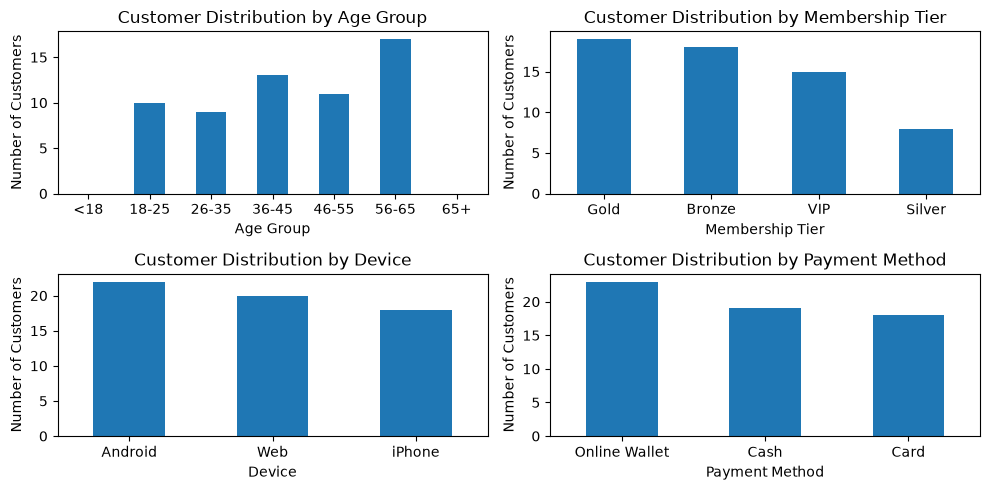

In [10]:
fig, axes = plt.subplots(2,2, figsize=(10, 5))

for col_title, col_value_counts, ax, x_label in [
    ('Customer Distribution by Age Group', age_counts, axes[0, 0], 'Age Group'),
    ('Customer Distribution by Membership Tier', membership_counts, axes[0, 1], 'Membership Tier'),
    ('Customer Distribution by Device', device_counts, axes[1, 0], 'Device'),
    ('Customer Distribution by Payment Method', payment_method_counts, axes[1, 1], 'Payment Method'),
]:
    col_value_counts.plot(kind='bar', ax=ax)
    ax.set_title(col_title);
    ax.set_xlabel(x_label);
    ax.set_ylabel('Number of Customers');
    ax.tick_params(axis='x', rotation=0);
    
plt.tight_layout()
plt.show()

## 2. City for invest

In [11]:
location_df = df.dropna(
    subset=["province", "city", "customer_id", "total_spending", "satisfaction_score", "purchase_count"]
).copy()


location_df["avg_order_value"] = location_df["total_spending"] / location_df["purchase_count"]


city_summary = (
    location_df.groupby(["province", "city"], as_index=False)
    .agg(
        customer_count=("customer_id", "nunique"),
        total_revenue=("total_spending", "sum"),
        avg_customer_spending=("total_spending", "mean"),
        avg_purchase_count=("purchase_count", "mean"),
        avg_order_value=("avg_order_value", "mean"),
        avg_satisfaction=("satisfaction_score", "mean")
    )
)

city_summary = city_summary[city_summary["customer_count"] >= 3].copy()
top_cities_total_revenue = city_summary.nlargest(10, "total_revenue").sort_values("total_revenue")
top_cities_avg_customer_spending = city_summary.nlargest(10, "avg_customer_spending").sort_values("avg_customer_spending")

display(top_cities_total_revenue.sort_values("total_revenue", ascending=False))

,province,city,customer_count,total_revenue,avg_customer_spending,avg_purchase_count,avg_order_value,avg_satisfaction
5,Khorasan,Mashhad,11,64118.44,5828.949091,22.636364,283.658042,2.909091
1,East Azerbaijan,Tabriz,12,36192.49,3016.040833,15.750000,238.901667,3.000000
0,Alborz,Karaj,7,26189.81,3741.401429,16.000000,211.440000,2.857143
6,Khuzestan,Ahvaz,8,23384.78,2923.097500,13.875000,238.368571,3.500000
4,Isfahan,Isfahan,5,21975.32,4395.064000,19.800000,212.680000,4.400000
2,Fars,Shiraz,6,20715.92,3452.653333,16.333333,180.983333,2.000000
3,Gilan,Rasht,5,15168.54,3033.708000,16.400000,241.554000,2.600000
7,Tehran,Tehran,6,15161.29,2526.881667,17.166667,172.930000,2.666667


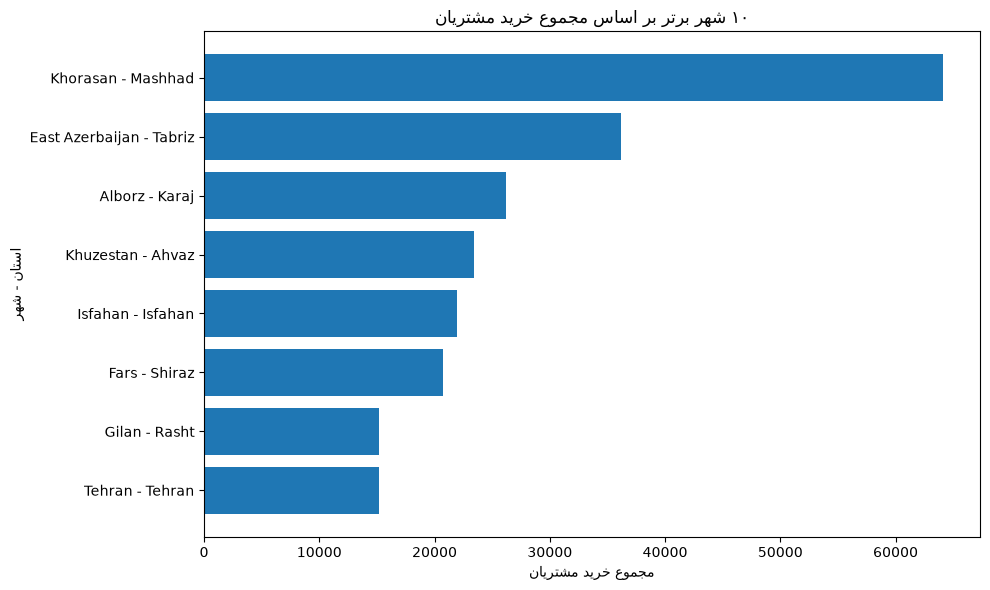

In [12]:
labels = top_cities_total_revenue["province"] + " - " + top_cities_total_revenue["city"]
plt.figure(figsize=(10, 6))
plt.barh(labels, top_cities_total_revenue["total_revenue"])
plt.title("۱۰ شهر برتر بر اساس مجموع خرید مشتریان")
plt.xlabel("مجموع خرید مشتریان")
plt.ylabel("استان - شهر")
plt.tight_layout()
plt.show()

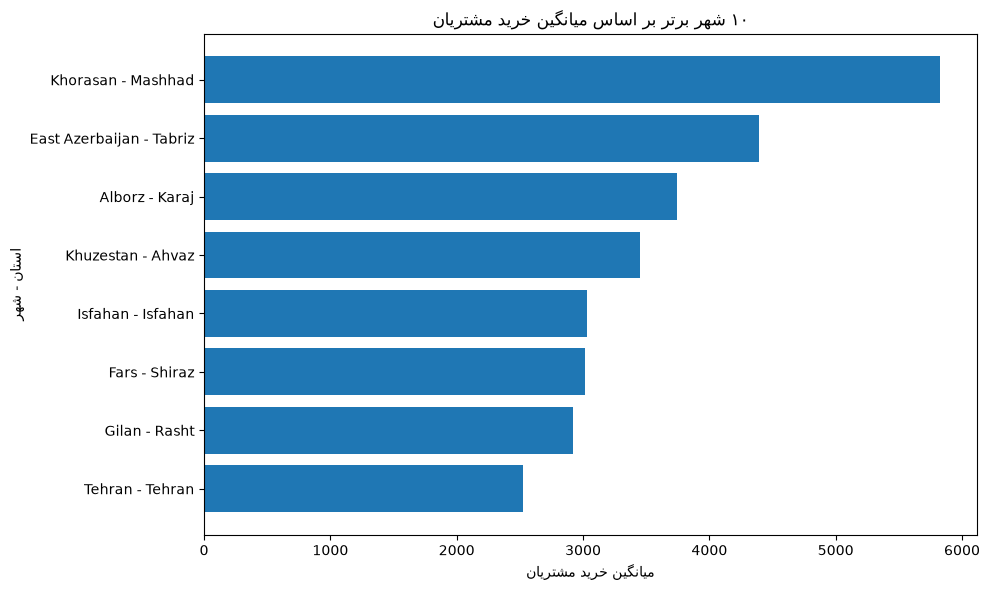

In [13]:
plt.figure(figsize=(10, 6))
plt.barh(labels, top_cities_avg_customer_spending["avg_customer_spending"])
plt.title("۱۰ شهر برتر بر اساس میانگین خرید مشتریان")
plt.xlabel("میانگین خرید مشتریان")
plt.ylabel("استان - شهر")
plt.tight_layout()
plt.show()

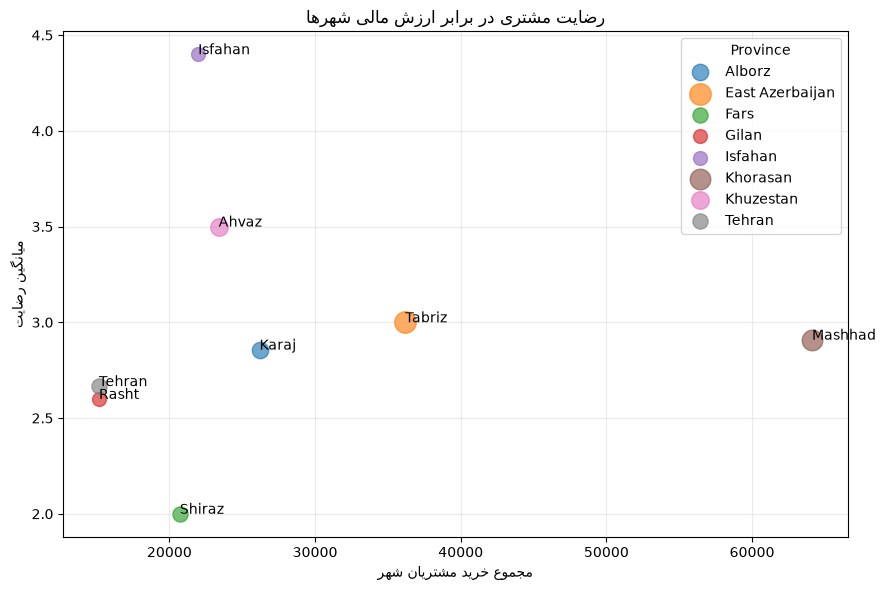

In [14]:
plt.figure(figsize=(9, 6))

for province, group in city_summary.groupby("province"):
    plt.scatter(
        group["total_revenue"],
        group["avg_satisfaction"],
        s=group["customer_count"] * 20,
        alpha=0.65,
        label=province
    )
    

plt.legend(title="Province")

for _, row in city_summary.iterrows():
    plt.annotate(
        row["city"],
        (row["total_revenue"], row["avg_satisfaction"])
    )
    
plt.title("رضایت مشتری در برابر ارزش مالی شهرها")
plt.xlabel("مجموع خرید مشتریان شهر")
plt.ylabel("میانگین رضایت")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [15]:
recommended_city = city_summary.sort_values(
    ["total_revenue", "avg_satisfaction", "customer_count"],
    ascending=[False, False, False]
).head(1)
recommended_city

,province,city,customer_count,total_revenue,avg_customer_spending,avg_purchase_count,avg_order_value,avg_satisfaction
5,Khorasan,Mashhad,11,64118.44,5828.949091,22.636364,283.658042,2.909091
